
# Twitter & Reddit Sentiment Analysis Using PySpark

This project aims to build an end-to-end sentiment analysis pipeline using PySpark, applied on combined Twitter and Reddit text data. The analysis involves exploring raw text, cleaning it, transforming it into machine-learning-ready features, and training multiple classifiers to automatically detect sentiment categories such as positive, neutral, and negative.

In [3]:
import findspark
findspark.init()

import pyspark
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("Projects").getOrCreate()#Creating spark session

cores = spark._jsc.sc().getExecutorMemoryStatus().keySet().size()
appid = spark._jsc.sc().applicationId()
spark

25/11/28 09:17:36 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


# Loading the Dataset

In [2]:
path = "archive/"
import glob

paths = glob.glob(path + "*.csv")
paths

['archive/Reddit_Data.csv', 'archive/Twitter_Data.csv']

In [3]:
from pyspark.sql.functions import col

dfs = []

for file in paths:    
    df = spark.read.option("header", True).csv(file)
    
    # Geting original column names
    cols = df.columns
    
    # Renaming fthe two columns
    df = df.withColumnRenamed(cols[0], "message") \
           .withColumnRenamed(cols[1], "label")
    
    dfs.append(df)

# combining all datasets
raw = dfs[0]
for d in dfs[1:]:
    raw = raw.unionByName(d)

print("Total rows loaded:", raw.count())
raw.show(5)

Total rows loaded: 230436
+--------------------+-----+
|             message|label|
+--------------------+-----+
| family mormon ha...|    1|
|buddhism has very...|    1|
|seriously don say...|   -1|
|what you have lea...|    0|
|for your own bene...|    1|
+--------------------+-----+
only showing top 5 rows


In [4]:
df.printSchema()

root
 |-- message: string (nullable = true)
 |-- label: string (nullable = true)



# Exploratory Data Analysis (EDA)

The goals of EDA are to:

- Understand the distribution of sentiment labels

- Inspect the length and quality of text messages

- Detect missing or malformed entries

- View sample messages

- Get basic statistics to inform later preprocessing steps

In [5]:
from pyspark.sql.functions import length, count, isnan

In [6]:
# Showing unique labels and their counts
label_dist = raw.groupBy("label").count().orderBy("count", ascending=False)
label_dist.show()

+-----+-----+
|label|count|
+-----+-----+
|    1|86225|
|    0|66547|
|   -1|42909|
| NULL|34755|
+-----+-----+



/var/folders/yt/9l8h8sxj6jbdkw_fcc78cyv00000gn/T/ipykernel_11979/3145277130.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='label', y='count', data=label_dist_pd, palette='viridis')


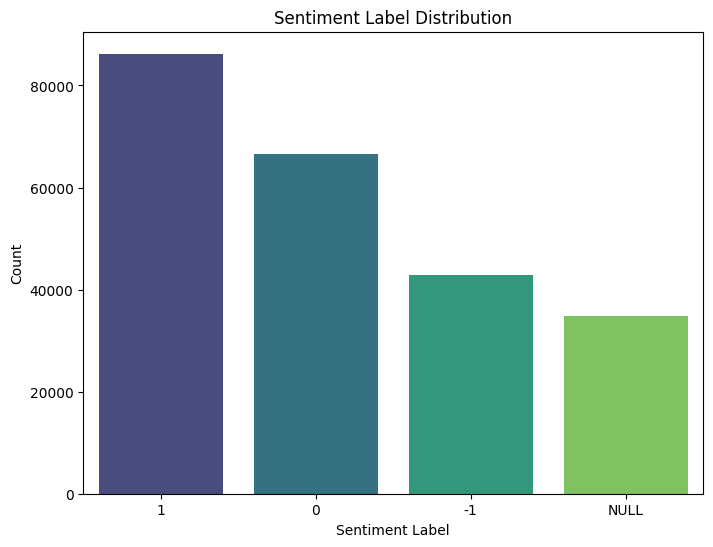

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Converting to Pandas for easy plotting
label_dist_pd = label_dist.toPandas()

# replacing NULL with a string label for clarity
label_dist_pd['label'] = label_dist_pd['label'].fillna('NULL')

# Plot
plt.figure(figsize=(8,6))
sns.barplot(x='label', y='count', data=label_dist_pd, palette='viridis')
plt.title('Sentiment Label Distribution')
plt.xlabel('Sentiment Label')
plt.ylabel('Count')
plt.show()

In [9]:
# Adding message length column to inspect text length distribution
raw = raw.withColumn("length", length(col("message")))

# Show basic statistics of message length
raw.describe(["length"]).show()

+-------+------------------+
|summary|            length|
+-------+------------------+
|  count|            230333|
|   mean|117.10085832251566|
| stddev|155.82950132650905|
|    min|                 1|
|    max|              8665|
+-------+------------------+



In [10]:
# average length of messages per label
from pyspark.sql.functions import avg

avg_length_per_label = raw.groupBy("label").agg(avg("length").alias("avg_length")).orderBy("label")
avg_length_per_label.show()

+-----+------------------+
|label|        avg_length|
+-----+------------------+
| NULL|58.310545245288445|
|   -1|151.62871725552344|
|    0|  78.6139120488818|
|    1|153.27454073111895|
+-----+------------------+



/var/folders/yt/9l8h8sxj6jbdkw_fcc78cyv00000gn/T/ipykernel_11979/2676343291.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='label', y='avg_length', data=avg_length_pd, palette='coolwarm')


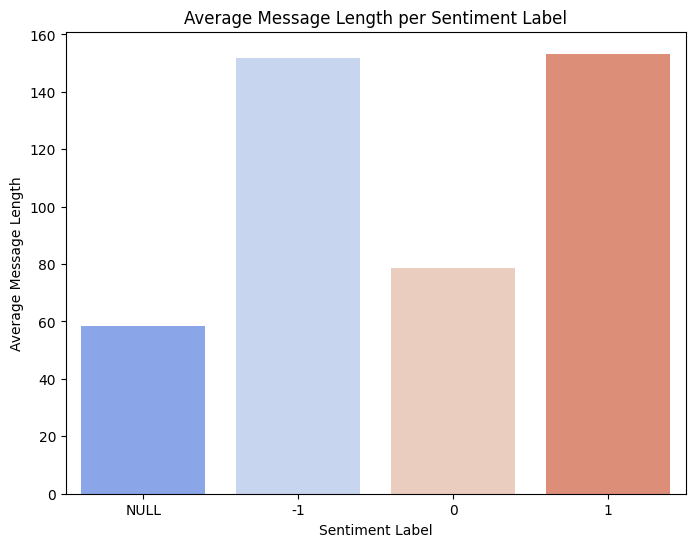

In [11]:
# Convert to Pandas
avg_length_pd = avg_length_per_label.toPandas()
avg_length_pd['label'] = avg_length_pd['label'].fillna('NULL')

# Plot
plt.figure(figsize=(8,6))
sns.barplot(x='label', y='avg_length', data=avg_length_pd, palette='coolwarm')
plt.title('Average Message Length per Sentiment Label')
plt.xlabel('Sentiment Label')
plt.ylabel('Average Message Length')
plt.show()

In [12]:
# checks missing values in message or label
from pyspark.sql.functions import when

missing = raw.select(
    count(when(col("message").isNull(), 1)).alias("missing_message"),
    count(when(col("label").isNull(), 1)).alias("missing_label")
)
missing.show()

+---------------+-------------+
|missing_message|missing_label|
+---------------+-------------+
|            103|        34755|
+---------------+-------------+



In [13]:
# sample messages by sentiment
print("Examples: Negative (-1)")
raw.filter(col("label") == "-1").select("message", "length").show(2, truncate=True)

Examples: Negative (-1)
+--------------------+------+
|             message|length|
+--------------------+------+
|seriously don say...|   460|
|you should all si...|   146|
+--------------------+------+
only showing top 2 rows


In [14]:
print("Examples: Neutral (0)")
raw.filter(col("label") == "0").select("message", "length").show(3, truncate=True)

print("Examples: Positive (1)")
raw.filter(col("label") == "1").select("message", "length").show(3, truncate=True)

Examples: Neutral (0)
+--------------------+------+
|             message|length|
+--------------------+------+
|what you have lea...|   168|
|jesus was zen mee...|    24|
|              zarus |     7|
+--------------------+------+
only showing top 3 rows
Examples: Positive (1)
+--------------------+------+
|             message|length|
+--------------------+------+
| family mormon ha...|   261|
|buddhism has very...|  1269|
|for your own bene...|   691|
+--------------------+------+
only showing top 3 rows


In [15]:
raw.printSchema()

root
 |-- message: string (nullable = true)
 |-- label: string (nullable = true)
 |-- length: integer (nullable = true)



Total number of unique words collected for visualization: 500


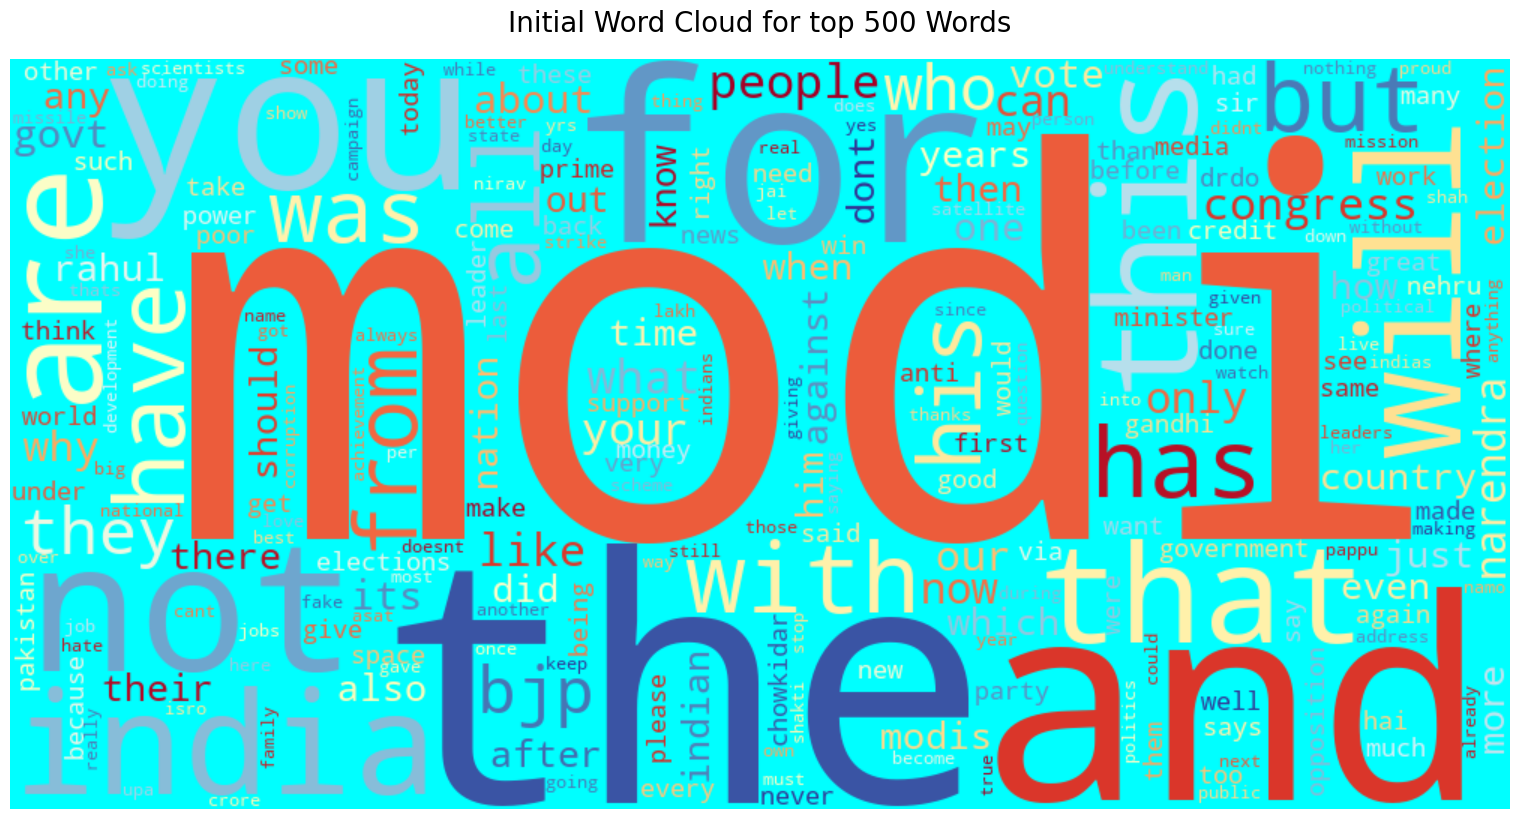

In [17]:
import pyspark.sql.functions as F
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import re

# messages processing
df_processed = df.withColumn("message_lower", F.lower(F.col("message")))

# remove punctuation, numbers, and non-word characters
df_processed = df_processed.withColumn(
    "cleaned_message",
    F.regexp_replace(F.col("message_lower"), "[^a-z\s]", " ")
)

# Tokenize, split, explode
df_words = df_processed.withColumn(
    "word",
    F.explode(F.split(F.col("cleaned_message"), "\s+"))
)
# removing empty strings
df_words = df_words.filter(F.length(F.col("word")) > 2)
df_words = df_words.filter(F.col("word") != "")

# frequency of each word
word_counts_df = df_words.groupBy("word").count().orderBy(F.desc("count"))

top_n = 500
word_frequency = word_counts_df.limit(top_n).collect()

# Convert the collected list of Row objects into a standard Python dictionary {word: count}
word_freq_map = {row['word']: row['count'] for row in word_frequency}

print(f"Total number of unique words collected for visualization: {len(word_freq_map)}")

# initializing and generating the WordCloud object
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='cyan',#
    max_words=top_n,
    colormap='RdYlBu', # colormap for words
    min_font_size=12
).generate_from_frequencies(word_freq_map)

# ploting the general wordcloud
plt.figure(figsize=(15, 8))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off") # hide the axes
plt.title(f'Initial Word Cloud for top {len(word_freq_map)} Words', color='black', fontsize=20, pad=20)
plt.tight_layout(pad=0)
plt.show()


# Data Cleaning

In [16]:
from pyspark.sql.functions import col, regexp_extract_all, regexp_replace, udf, lower, trim, split
from pyspark.sql.types import ArrayType, StringType
import re
import string

# removing rows with NULL labels or messages
# -----------------------------------------------------------
cleaned = raw.filter(col("label").isNotNull() & col("message").isNotNull())

print("Rows after dropping NULL labels and messages:", cleaned.count())

# -----------------------------------------------------------
# extracting hashtags BEFORE removing '#' from text
# -----------------------------------------------------------
def extract_hashtags(text):
    if text is None:
        return []
    return re.findall(r"#\w+", text)

extract_hashtags_udf = udf(extract_hashtags, ArrayType(StringType()))

cleaned = cleaned.withColumn("hashtags", extract_hashtags_udf(col("message")))



Rows after dropping NULL labels and messages: 195578


In [17]:
# text cleaning

url_pattern = r'https?://\S+|www\.\S+'
mention_pattern = r'@\w+'
html_pattern = r'<.*?>'
number_pattern = r'\b\d+\b'

def clean_text(text):
    if text is None:
        return None
        
    text = text.lower()

    # remove URLs
    text = re.sub(url_pattern, " ", text)

    # remove mentions
    text = re.sub(mention_pattern, " ", text)

    # remove HTML tags
    text = re.sub(html_pattern, " ", text)

    # remove numbers
    text = re.sub(number_pattern, " ", text)

    # remove punctuation
    text = text.translate(str.maketrans(string.punctuation, " " * len(string.punctuation)))

    # collapse whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text

clean_text_udf = udf(clean_text, StringType())

cleaned = cleaned.withColumn("clean_message", clean_text_udf(col("message")))

# remove empty cleaned rows

cleaned = cleaned.filter(col("clean_message") != "")
print("Rows after removing empty cleaned messages:", cleaned.count())

[Stage 40:========>                                                 (1 + 6) / 7]

Rows after removing empty cleaned messages: 195323


In [18]:
#tokenize clean_message for trending keywords later
cleaned = cleaned.withColumn("tokens_raw", split(col("clean_message"), " "))
cleaned.select("message", "clean_message", "tokens_raw", "label")\
       .show(4, truncate=True)

+--------------------+--------------------+--------------------+-----+
|             message|       clean_message|          tokens_raw|label|
+--------------------+--------------------+--------------------+-----+
| family mormon ha...|family mormon hav...|[family, mormon, ...|    1|
|buddhism has very...|buddhism has very...|[buddhism, has, v...|    1|
|seriously don say...|seriously don say...|[seriously, don, ...|   -1|
|what you have lea...|what you have lea...|[what, you, have,...|    0|
+--------------------+--------------------+--------------------+-----+
only showing top 4 rows


# Label Normalization

In this section, we convert the sentiment labels into a clean and consistent format suitable for machine learning.

The dataset uses sentiment labels

- 1  -> positive

- 0  -> neutral

- -1 -> negative

In [19]:
from pyspark.sql.functions import col, when

# convert label column to integer
cleaned_n = cleaned.withColumn("label", col("label").cast("int"))

# Remove any rows with invalid labels
cleaned_n = cleaned_n.filter(col("label").isin(-1, 0, 1))

print("Rows after ensuring valid labels:", cleaned.count())

# descriptive labels (text form)
cleaned_n = cleaned_n.withColumn(
    "label_str",
    when(col("label") == -1, "negative")
    .when(col("label") == 0, "neutral")
    .when(col("label") == 1, "positive")
).withColumn(
    "label",
    when(col("label") == -1, 2)#transforming -1 to 2 to avoid -ves in the model
    .when(col("label") == 0, 0)
    .when(col("label") == 1, 1)
)

cleaned_n = cleaned_n.withColumn("label", col("label").cast("int"))#reconverting to into after transformation
# results
cleaned_n.select("message", "clean_message", "label", "label_str")\
       .show(10, truncate=True)

Rows after ensuring valid labels: 195323
+--------------------+--------------------+-----+---------+
|             message|       clean_message|label|label_str|
+--------------------+--------------------+-----+---------+
| family mormon ha...|family mormon hav...|    1| positive|
|buddhism has very...|buddhism has very...|    1| positive|
|seriously don say...|seriously don say...|    2| negative|
|what you have lea...|what you have lea...|    0|  neutral|
|for your own bene...|for your own bene...|    1| positive|
|you should all si...|you should all si...|    2| negative|
| was teens when d...|was teens when di...|    1| positive|
|jesus was zen mee...|jesus was zen mee...|    0|  neutral|
|there are two var...|there are two var...|    2| negative|
|dont worry about ...|dont worry about ...|    1| positive|
+--------------------+--------------------+-----+---------+
only showing top 10 rows


# Feature Engineering (Tokenization, Stopwords Removal , TF-IDF)

1. Stop word removal

   Removes non-informative words (“the”, “is”, “at”, “and”, ..)

3. CountVectorizer

   Builds a vocabulary and convert tokens to sparse frequency vectors.

5. IDF (Inverse Document Frequency)

   Downweight very common words, upweight important ones.


In [20]:
cleaned_n.columns

['message',
 'label',
 'length',
 'hashtags',
 'clean_message',
 'tokens_raw',
 'label_str']

In [21]:
from pyspark.ml.feature import StopWordsRemover, CountVectorizer, IDF
from pyspark.ml import Pipeline

# rm stopwords: tokens_raw -> tokens_filtered
stopwords_remover = StopWordsRemover(
    inputCol="tokens_raw",
    outputCol="tokens_filtered"
)

# CountVectorizer: tokens_filtered -> raw_features
cv = CountVectorizer(
    inputCol="tokens_filtered",
    outputCol="raw_features",
    vocabSize=50000,
    minDF=5
)

# IDF: raw_features -> features (final vector)

idf = IDF(
    inputCol="raw_features",
    outputCol="features"
)

# Build Feature Pipeline

feature_pipeline = Pipeline(stages=[
    stopwords_remover,
    cv,
    idf
])

# fitting the pipeline
feature_model = feature_pipeline.fit(cleaned_n)

# transforming dataset
featured = feature_model.transform(cleaned_n)


In [22]:
# Preview results
featured.select(
    "clean_message",
    "tokens_raw",
    "tokens_filtered",
    "features",
    "label",
    "label_str"
).show(5, truncate=True)

+--------------------+--------------------+--------------------+--------------------+-----+---------+
|       clean_message|          tokens_raw|     tokens_filtered|            features|label|label_str|
+--------------------+--------------------+--------------------+--------------------+-----+---------+
|family mormon hav...|[family, mormon, ...|[family, mormon, ...|(24629,[4,12,46,5...|    1| positive|
|buddhism has very...|[buddhism, has, v...|[buddhism, much, ...|(24629,[4,6,14,25...|    1| positive|
|seriously don say...|[seriously, don, ...|[seriously, say, ...|(24629,[2,4,6,16,...|    2| negative|
|what you have lea...|[what, you, have,...|[learned, want, t...|(24629,[27,120,23...|    0|  neutral|
|for your own bene...|[for, your, own, ...|[benefit, may, wa...|(24629,[27,31,56,...|    1| positive|
+--------------------+--------------------+--------------------+--------------------+-----+---------+
only showing top 5 rows


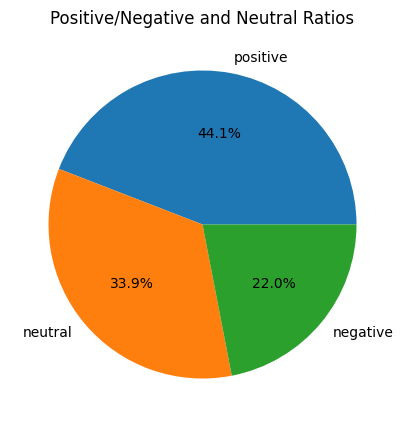

In [15]:
# plotting the ratio of positive, negative annd neutrals
label_counts = (
    featured
    .filter(featured.label_str.isin("positive", "negative","neutral"))
    .groupBy("label_str")
    .count()
    .toPandas()
)
label_counts

import matplotlib.pyplot as plt

plt.figure(figsize=(5,5))
plt.pie(
    label_counts["count"],
    labels=label_counts["label_str"],
    autopct="%1.1f%%"
)
plt.title("Positive/Negative and Neutral Ratios")
plt.show()


In [25]:
def generate_word_cloud(df_filtered, label_name, top_n=300):
    """
    This function does word counting on the PySpark DataFrame, collects results, and generates a WordCloud
    """
    # xplode the pre-filtered tokens array into rows
    df_words = df_filtered.withColumn(
        "word",
        F.explode(F.col("tokens_filtered"))
    )

    #  Count word freq
    word_counts_df = df_words.groupBy("word").count().orderBy(F.desc("count"))

    # top N words 
    word_frequency = word_counts_df.limit(top_n).collect()
    word_freq_map = {row['word']: row['count'] for row in word_frequency}

    # Generate and display the WordCloud
    print(f"Generating Word Cloud for: {label_name.upper()}")

    color = '#1f77b4' if label_name == 'positive' else '#d62728' # Blue for positive, Red for negative
    
    wordcloud = WordCloud(
        width=1000,
        height=500,
        background_color='white',
        max_words=top_n,
        # color settings
        colormap='Blues' if label_name == 'positive' else 'Reds', 
        min_font_size=12
    ).generate_from_frequencies(word_freq_map)

    plt.figure(figsize=(15, 8))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(f'Word Cloud for {label_name.upper()} Messages', fontsize=20, color=color, pad=20)
    plt.tight_layout(pad=0)
    plt.show()


Generating Word Cloud for: POSITIVE


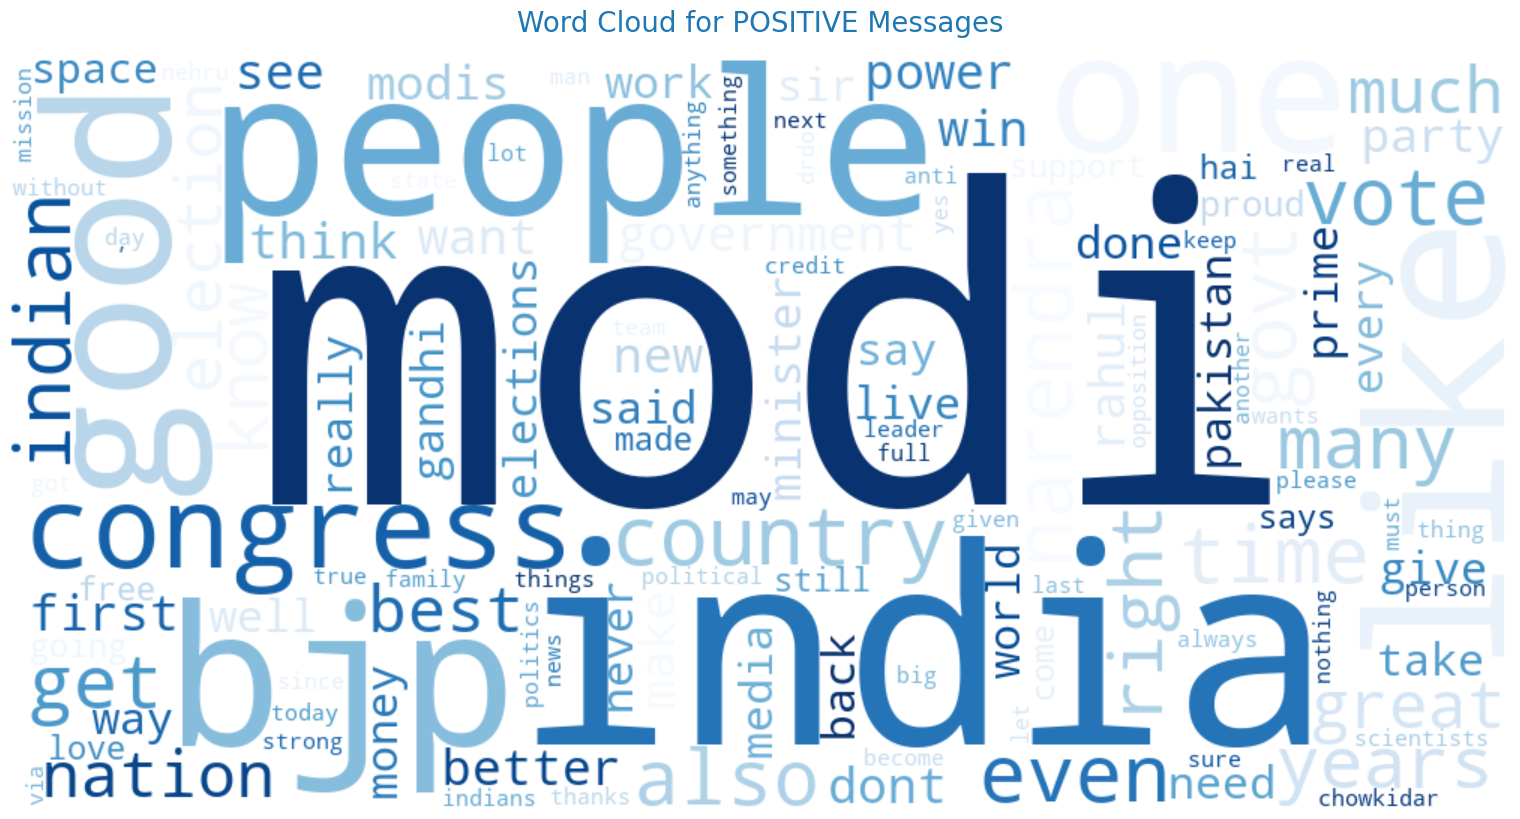

In [26]:
# Filter for positive messages
positive_df = featured.filter(F.col("label_str") == "positive")

# plot the word clouds
generate_word_cloud(positive_df, "positive")

Generating Word Cloud for: NEGATIVE


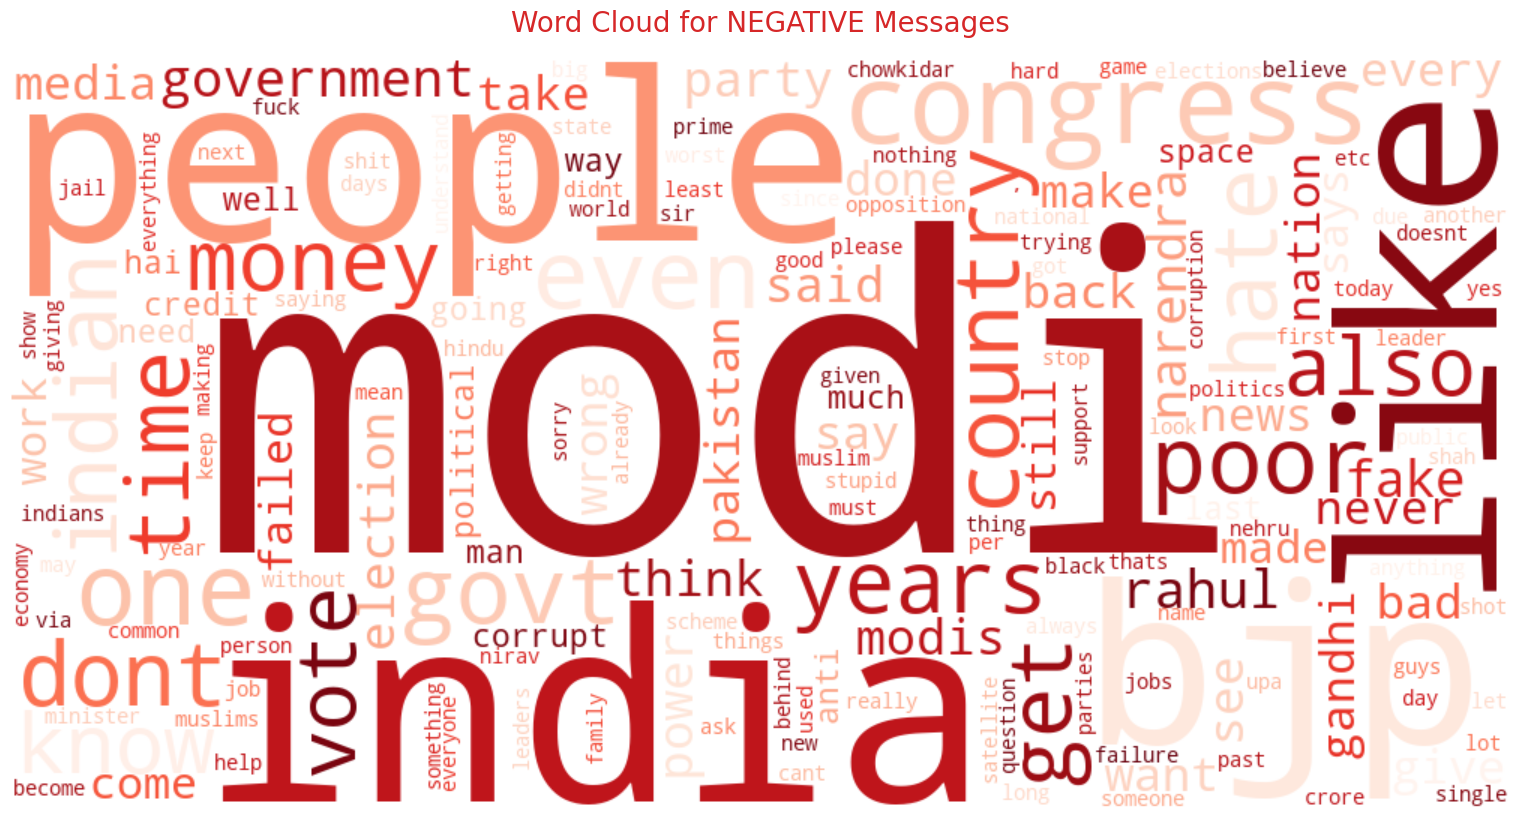

In [27]:
# filter negative messages
negative_df = featured.filter(F.col("label_str") == "negative")
# plotting
generate_word_cloud(negative_df, "negative")

# Train/Test Split

1. Training Set

    Used to fit the model and learn patterns from the data.

2. Test Set

    Used to evaluate the model’s performance on unseen data.

- <b>Importance</b>

    Splitting the data <i> prevents overfitting and gives a realistic estimate</i> of how well the model will generalize to new text.

In [23]:
train_df, test_df = featured.randomSplit([0.85, 0.15], seed=42)

print("Training rows:", train_df.count())
print("Testing rows:", test_df.count())

# Quick preview
train_df.select("clean_message", "label", "features").show(3, truncate=True)


Training rows: 166272


Testing rows: 29051


[Stage 61:>                                                         (0 + 1) / 1]

+--------------------+-----+--------------------+
|       clean_message|label|            features|
+--------------------+-----+--------------------+
|please forward th...|    1|(24629,[16,45,63,...|
|                 jpg|    0|(24629,[1736],[6....|
|new achievement u...|    1|(24629,[56,195,14...|
+--------------------+-----+--------------------+
only showing top 3 rows


# Logistic Regression

This is a classic and powerful baseline model for text classification and often performs surprisingly well on TF-IDF features.

Why Logistic Regression?

- Works extremely well with sparse TF-IDF vectors

- Fast to train

- Often sets a strong baseline for sentiment classification

- Produces clear decision boundaries

In [25]:
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Train Logistic Regression Model
# ----------------------------------------------------
lr = LogisticRegression(
    featuresCol="features",
    labelCol="label",
    maxIter=20,
    regParam=0.0
)

lr_model = lr.fit(train_df)

# evaluate TS
pred_lr = lr_model.transform(test_df)

# accuracy
evaluator_acc = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)

# F1 Score
evaluator_f1 = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="f1"
)

acc_lr = evaluator_acc.evaluate(pred_lr)
f1_lr = evaluator_f1.evaluate(pred_lr)


25/11/28 09:03:23 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
25/11/28 09:03:32 WARN DAGScheduler: Broadcasting large task binary with size 1142.4 KiB
25/11/28 09:03:39 WARN DAGScheduler: Broadcasting large task binary with size 1142.4 KiB
                                                                                

In [26]:
print("Logistic Regression Performance:")
print(f"Accuracy: {acc_lr:.4f}")
print(f"F1 Score: {f1_lr:.4f}")

print("Sample predictions")
pred_lr.select(
    "clean_message",
    "label_str",
    "prediction"
).show(10, truncate=True)

Logistic Regression Performance:
Accuracy: 0.8103
F1 Score: 0.8101
Sample predictions


25/11/28 09:05:22 WARN DAGScheduler: Broadcasting large task binary with size 1124.6 KiB
[Stage 113:>                                                        (0 + 1) / 1]

+--------------------+---------+----------+
|       clean_message|label_str|prediction|
+--------------------+---------+----------+
|think punjabi goo...| positive|       0.0|
|pdf have all read...| negative|       2.0|
|utc 23modi and fo...|  neutral|       0.0|
|28mumbai the gran...| positive|       2.0|
|5ppr team dynasty...| positive|       0.0|
|            5yn5o2xg|  neutral|       0.0|
|dhirubhai ambani ...| positive|       1.0|
|         9jy67oz0fie|  neutral|       0.0|
|              aadhar|  neutral|       0.0|
|aap shazia ilmi m...| negative|       2.0|
+--------------------+---------+----------+
only showing top 10 rows


# Naive Bayes

In [27]:
from pyspark.ml.classification import NaiveBayes

nb = NaiveBayes(
    featuresCol="features",
    labelCol="label",
    modelType="multinomial"
)

nb_model = nb.fit(train_df)
pred_nb = nb_model.transform(test_df)

acc_rf = evaluator_acc.evaluate(pred_nb)
f1_rf = evaluator_f1.evaluate(pred_nb)

25/11/28 09:05:37 WARN DAGScheduler: Broadcasting large task binary with size 1137.7 KiB
25/11/28 09:05:43 WARN DAGScheduler: Broadcasting large task binary with size 1137.7 KiB
                                                                                

In [28]:
print("NB Performance")
print(f"Accuracy: {acc_rf:.4f}")
print(f"F1 Score: {f1_rf:.4f}")

# sample predictions
pred_nb.select(
    "clean_message",
    "label_str",
    "prediction"
).show(10, truncate=True)

NB Performance
Accuracy: 0.7003
F1 Score: 0.7032


25/11/28 09:05:58 WARN DAGScheduler: Broadcasting large task binary with size 1119.8 KiB
[Stage 121:>                                                        (0 + 1) / 1]

+--------------------+---------+----------+
|       clean_message|label_str|prediction|
+--------------------+---------+----------+
|think punjabi goo...| positive|       1.0|
|pdf have all read...| negative|       1.0|
|utc 23modi and fo...|  neutral|       2.0|
|28mumbai the gran...| positive|       2.0|
|5ppr team dynasty...| positive|       0.0|
|            5yn5o2xg|  neutral|       1.0|
|dhirubhai ambani ...| positive|       1.0|
|         9jy67oz0fie|  neutral|       1.0|
|              aadhar|  neutral|       0.0|
|aap shazia ilmi m...| negative|       2.0|
+--------------------+---------+----------+
only showing top 10 rows


# Random Forest Classifier
Random Forest is an ensemble of many decision trees.
For text classification, it provides:

### Strengths

- Works well with nonlinear patterns

- More stable than a single decision tree

- Handles unbalanced classes better

- Non-parametric (does not assume linear separability)

In [29]:
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Train RF
rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="label",
    numTrees=100, #higher trees crashes the kernel
    maxDepth=15
)

rf_model = rf.fit(train_df)

# Evaluate on tests set data
pred_rf = rf_model.transform(test_df)

evaluator_acc = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)

evaluator_f1 = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="f1"
)

acc_rf = evaluator_acc.evaluate(pred_rf)
f1_rf = evaluator_f1.evaluate(pred_rf)

ERROR! Session/line number was not unique in database. History logging moved to new session 216


ConnectionRefusedError: [Errno 61] Connection refused

In [ ]:
print("Random Forest Performance")
print(f"Accuracy: {acc_rf:.4f}")
print(f"F1 Score: {f1_rf:.4f}")

#### RF struggles with this dataset due to 
##### very high-dimensional sparse vectors
##### many rare words
##### non-linear patterns

## Model Evaluation, Comparison

In [35]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
import pandas as pd

def evaluate_models(model_dict, label_col="label", pred_col="prediction"):
    
    evaluator_acc = MulticlassClassificationEvaluator(
        labelCol=label_col,
        predictionCol=pred_col,
        metricName="accuracy"
    )
    
    evaluator_f1 = MulticlassClassificationEvaluator(
        labelCol=label_col,
        predictionCol=pred_col,
        metricName="f1"
    )
    
    results = []
    
    for name, preds in model_dict.items():
        acc = evaluator_acc.evaluate(preds)
        f1 = evaluator_f1.evaluate(preds)
        
        results.append({
            "Model": name,
            "Accuracy": round(acc, 4),
            "F1 Score": round(f1, 4)
        })
    
    return pd.DataFrame(results)

In [36]:
models = {
    "Logistic Regression": pred_lr,
    "Naive Bayes": pred_nb,
    "Random Forest": pred_rf
}

performance_table = evaluate_models(models)
print(performance_table)


25/11/23 12:49:15 WARN DAGScheduler: Broadcasting large task binary with size 1142.4 KiB
25/11/23 12:49:26 WARN DAGScheduler: Broadcasting large task binary with size 1142.4 KiB
25/11/23 12:49:37 WARN DAGScheduler: Broadcasting large task binary with size 1137.7 KiB
25/11/23 12:49:49 WARN DAGScheduler: Broadcasting large task binary with size 1137.7 KiB
25/11/23 12:50:03 WARN DAGScheduler: Broadcasting large task binary with size 3.5 MiB
25/11/23 12:50:20 WARN DAGScheduler: Broadcasting large task binary with size 3.5 MiB
                                                                                

                 Model  Accuracy  F1 Score
0  Logistic Regression    0.8103    0.8101
1          Naive Bayes    0.7003    0.7032
2        Random Forest    0.4464    0.2758


Based on the evaluation metrics and model behavior, Logistic Regression was selected as the final model for sentiment prediction out of the three. It provides the best balance of performance, reliability, and suitability for high-dimensional NLP tasks. This model is used in the final prediction pipeline and powers the real-time tweet sentiment analysis.

# Saving Model

In [40]:
import os

os.makedirs("models", exist_ok=True)
# Save the feature pipeline
feature_model.write().overwrite().save("models/feature_pipeline")

# Save Lo Reg model
lr_model.write().overwrite().save("models/logistic_regression_model")

In [4]:
from pyspark.ml import PipelineModel
from pyspark.ml.classification import LogisticRegressionModel
from pyspark.sql import Row
import re
import string

# Load the Models
# ----------------------------------------
feature_model = PipelineModel.load("models/feature_pipeline")
lr_model = LogisticRegressionModel.load("models/logistic_regression_model")



# Text Cleaning
# ------------------------
url_pattern = r'https?://\S+|www\.\S+'
mention_pattern = r'@\w+'
html_pattern = r'<.*?>'
number_pattern = r'\b\d+\b'

def clean_text(text):
    if text is None:
        return ""
    text = text.lower()
    text = re.sub(url_pattern, " ", text)
    text = re.sub(mention_pattern, " ", text)
    text = re.sub(html_pattern, " ", text)
    text = re.sub(number_pattern, " ", text)
    text = text.translate(str.maketrans(string.punctuation, " " * len(string.punctuation)))
    text = re.sub(r"\s+", " ", text).strip()
    return text



# Simple Prediction Function
# --------------------------------------------
from pyspark.ml.feature import RegexTokenizer

# tokenizer used during training
tokenizer = RegexTokenizer(
    inputCol="clean_message",
    outputCol="tokens_raw",
    pattern="\\W+"
)

def predict_label(text):
    cleaned = clean_text(text)
    
    # Create df
    df = spark.createDataFrame([Row(clean_message=cleaned)])
    
    # 1. Tokenize
    df = tokenizer.transform(df)

    # 2. Apply feature pipeline
    df_features = feature_model.transform(df)

    # 3. Predict
    prediction = lr_model.transform(df_features).select("prediction").collect()[0][0]
    
    label_map = {0: "neutral", 1: "positive", 2: "negative"}
    return label_map[int(prediction)]

In [5]:
# Quick Test

predict_label("it is my birthday today, i am very happy about this")

25/11/28 09:18:18 WARN DAGScheduler: Broadcasting large task binary with size 1019.8 KiB
                                                                                

'positive'

# Live Straming tweets from Tweeter

In [7]:
bearer = "AAAAAAAAAAAAAAAAAAAAABHY5QEAAAAA1IIDNV4QzC2mZpyQm%2FlN82wGk9M%3DgWyysdzl2DHCFd5h2j6y9qMHmxmONgB0duuwg4AKA6yQdGHKmC"

In [8]:
import tweepy

client = tweepy.StreamingClient(
    bearer_token=bearer,
    wait_on_rate_limit=True
)


## Stream Listener
- Get tweet text
- Predict sentiment
- Print

In [10]:
import tweepy

client = tweepy.StreamingClient(
    bearer_token=bearer,
    wait_on_rate_limit=True
)

from tweepy import Client

client = Client(bearer_token=bearer)

def fetch_tweets_list(search_query):
    response = client.search_recent_tweets(
        query=search_query,
        max_results=5,        # API req: 10–100
        tweet_fields=["text"]
    )

    tweets = response.data
    tweet_msgs = []

    if tweets:
        for t in tweets:
            tweet_msgs.append(t.text)

        # print the first tweet 
        print("First Tweet:")
        print(tweet_msgs[0])

        return tweet_msgs
    else:
        print("No tweets found.")
        return []

tweet_msgs = fetch_tweets_list("UCI hosted in rwanda lang:en -is:retweet")

TooManyRequests: 429 Too Many Requests
Too Many Requests

In [62]:
print("\nList of tweet messages:")
print(tweet_msgs[3])


List of tweet messages:
...Broadbased Gafment consists of UDA and ODM( hawa wa kuosha sahani kama Mdvd and Weta wachana nao) but something is boiling in Kasipul....Who has suddenly become CLEVER!....RiggyG ebu chanua watu🤣


In [63]:
predict_label(tweet_msgs[1])

25/11/24 01:04:36 WARN DAGScheduler: Broadcasting large task binary with size 1019.8 KiB


'positive'

In [3]:
?pyspark.ml.classification

Object `pyspark.ml.classification` not found.
